## GitHub: 
https://github.com/Twinbo/Computational-Social-Science-2026

## Group Memebers:
Equal group contribution, Haseeb s244701, Malthe s246133 & David s230106

# Formalia

Please read the [assignment overview page](https://laura.alessandretti.com/comsocsci2026/wiki_pages/Assignments.html) carefully before proceeding. The page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

__If you fail to follow these simple instructions, it will negatively impact your grade!__

**Due date and time**: The assignment is due on Apr 7th at 23:59. Hand in your Jupyter notebook file (with extension `.ipynb`) via DTU Learn _(Assignment 2)_. 

Remember to include in the first cell of your notebook:
* the link to your group's Git repository 
* group members' contributions

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>
> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>
> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.
>
> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.
> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 
>
> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    



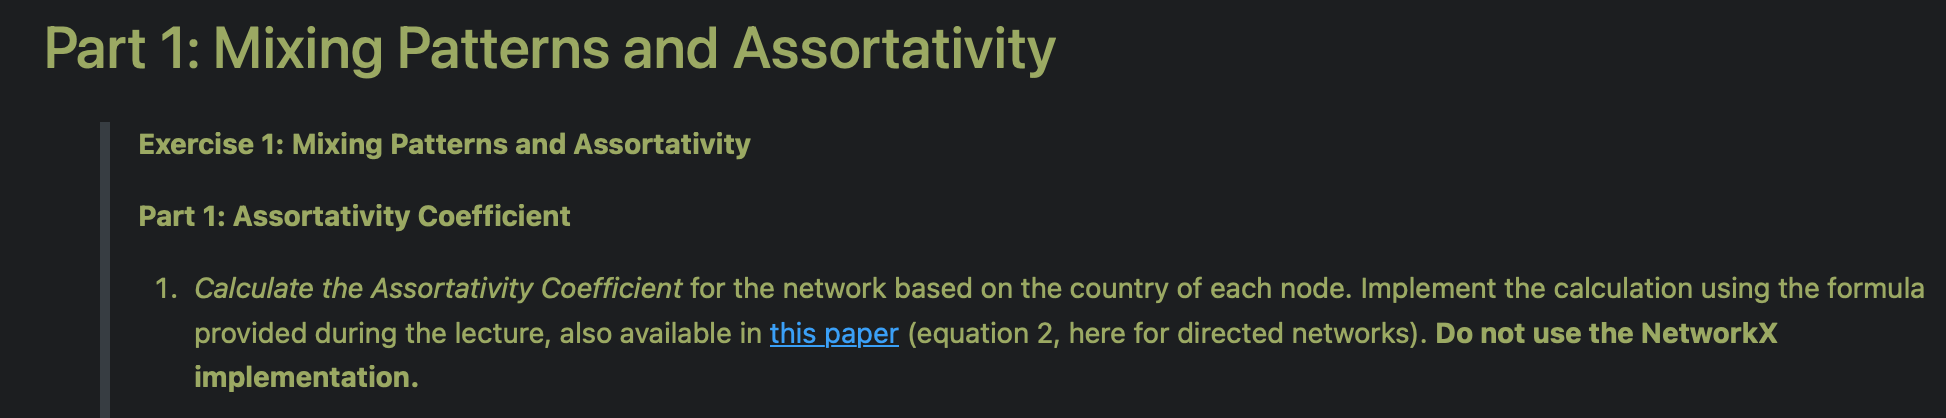

In [134]:
#Loading needed packages,functions and csv from previous weeks
import networkx as nx
from netwulf import visualize
import ast
import pandas as pd
import itertools as iter
from collections import Counter
import matplotlib
import random
#matplotlib.use("Agg")


df_final = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week 3/Final_data/D7_CSS_Authors.csv")
CSS_paper = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week 3/FInal_data/D8_CSS_Papers.csv")

def weighted_edge_fuc():
    CSS_paper = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week 3/FInal_data/D8_CSS_Papers.csv")
    weighted_edge = [()]
    uniqe_combi = []
    for combinations in CSS_paper["author_ids"]:
        actual_list = ast.literal_eval(combinations)
        uniqe_combi.extend(iter.combinations(sorted(set(actual_list)), 2))

    pair_counts = Counter(uniqe_combi)

    weighted_edge = [(author1, author2, count) for (author1, author2), count in pair_counts.items()]
    
    return weighted_edge


Now we can do the calculation from the paper using equation 2, which also can be seen in code in def G_Assortativity function. 



$r=\frac{\sum_i e_{i i}-\sum_i a_i b_i}{1-\sum_i a_i b_i}$

In [135]:
import pandas as pd
import numpy as np
import networkx as nx

# Build graph
G = nx.Graph()
G.add_weighted_edges_from(weighted_edge_fuc())

key_col = "author_id"
df_final = df_final[df_final[key_col].isin(G.nodes())].copy()

# clean missing values
df_final["country_code"] = df_final["country_code"].replace([np.inf, -np.inf], np.nan)
df_final["country_code"] = df_final["country_code"].fillna("Unknown")

# Convert entire dataframe to dict of dicts
attr_dict = df_final.set_index(key_col).to_dict(orient="index")

# Attach all attributes
nx.set_node_attributes(G, attr_dict)

# Remove nodes with unknown country
valid_nodes = [
    n for n in G.nodes
    if G.nodes[n].get("country_code") not in [None, "Unknown"]
]

G_valid = G.subgraph(valid_nodes).copy()
largest_cc = max(nx.connected_components(G_valid), key=len)
G_valid = G_valid.subgraph(largest_cc).copy()

def G_Assortativity(G_valid, statistic):
    # Collect categories
    categories = sorted({
        G_valid.nodes[n]["country_code"]
        for n in G_valid.nodes()
    })

    # Build mixing matrix
    M = pd.DataFrame(0.0, index=categories, columns=categories)

    for u, v in G_valid.edges():
        cu = G_valid.nodes[u]["country_code"]
        cv = G_valid.nodes[v]["country_code"]

        M.loc[cu, cv] += 1
        M.loc[cv, cu] += 1

    # Normalize to e_ij
    e = M / M.values.sum()

    # Compute marginals
    a = e.sum(axis=1)
    b = e.sum(axis=0)

    # Assortativity formula
    sum_eii = np.trace(e.values)
    sum_aibi = np.sum(a.values * b.values)

    r = (sum_eii - sum_aibi) / (1 - sum_aibi)

    if statistic:
        print("sum_i e_ii =", sum_eii)
        print("sum_i a_i b_i =", sum_aibi)
        print("Assortativity r =", r)
    
    else:
        return r

In [136]:
G_Assortativity(G_valid, False)

0.3545461109206213

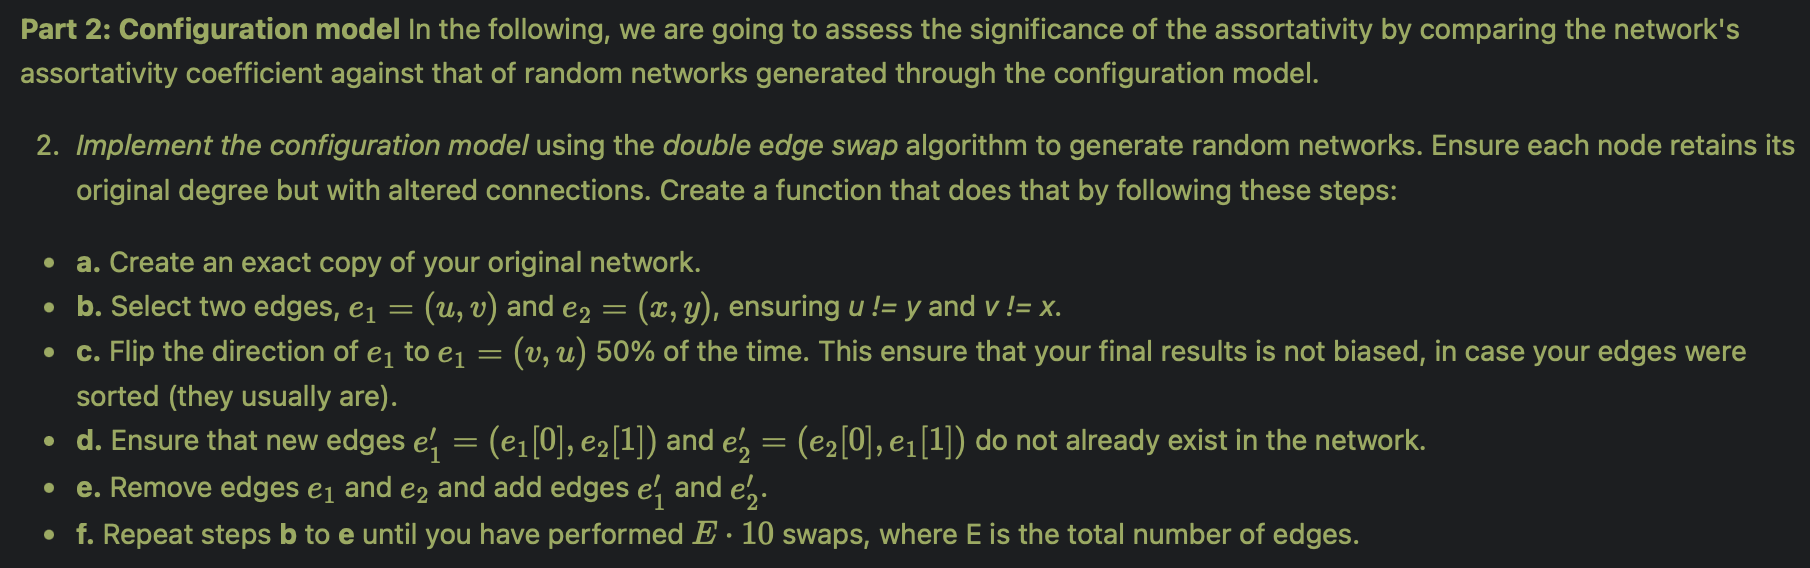

In [137]:
def randomize_G(G2, show_progress=False):
    G2 = G2.copy()

    def canon(a, b):
        return tuple(sorted((a, b)))

    edges = [canon(u, v) for u, v in G2.edges()]
    E = len(edges)

    it = range(E * 10)
    if show_progress:
        from tqdm.notebook import tqdm
        it = tqdm(it, desc="Edge swaps", leave=False)

    for _ in it:
        i, j = random.sample(range(E), 2)
        (u, v) = edges[i]
        (x, y) = edges[j]

        # avoid selfloops
        if u == y or x == v:
            continue

        # flip
        if random.random() < 0.5:
            u, v = v, u

        new1 = canon(u, y)
        new2 = canon(x, v)
        old1 = canon(*edges[i])
        old2 = canon(*edges[j])

        # avoid creating duplicate edges
        if new1 == new2:
            continue
        if G2.has_edge(*new1) or G2.has_edge(*new2):
            continue

        #ensure the old edges still exist
        if not G2.has_edge(*old1) or not G2.has_edge(*old2):
            continue

        G2.remove_edge(*old1)
        G2.remove_edge(*old2)
        G2.add_edge(*new1)
        G2.add_edge(*new2)

        edges[i] = new1
        edges[j] = new2

    return G2

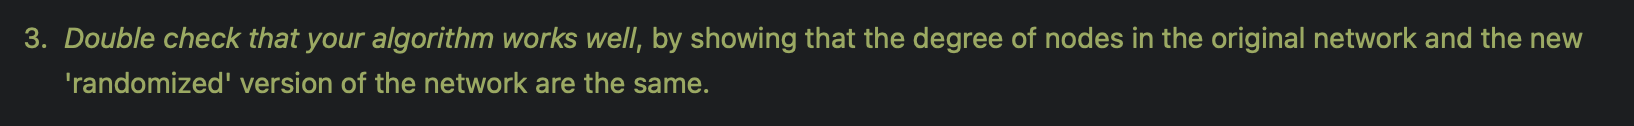

In [138]:
G2 = G.subgraph(valid_nodes).copy()
G2_random = randomize_G(G2, show_progress=True)

degrees = [d for _, d in G2.degree()]

print("Degree G statistics")
print("Average:", np.mean(degrees))
print("Median:", np.median(degrees))
print("Min:", np.min(degrees))
print("Max:", np.max(degrees))

degrees2 = [d for _, d in G2_random.degree()]

print("Degree G_random statistics")
print("Average:", np.mean(degrees2))
print("Median:", np.median(degrees2))
print("Min:", np.min(degrees2))
print("Max:", np.max(degrees2))

Edge swaps:   0%|          | 0/1151560 [00:00<?, ?it/s]

Degree G statistics
Average: 9.638905164476437
Median: 7.0
Min: 1
Max: 445
Degree G_random statistics
Average: 9.638905164476437
Median: 7.0
Min: 1
Max: 445


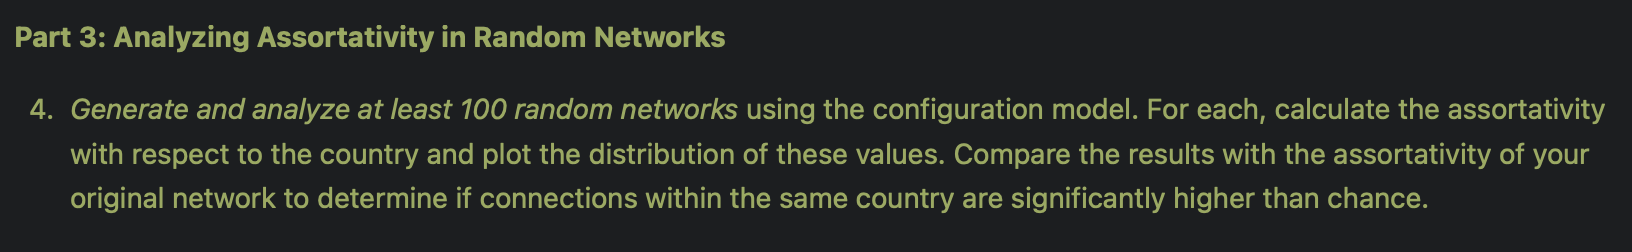

We made two versions of the code, the one below, and another which used multicore (MC) to make it faster. For the weekly tasked we used the MC version which halfed the time. The problem is that i could'nt make it work in a jypiter file, thus needed to make a assortativity_countries_MC.py script which does the same thing. We uploaded the scripts to the github, and below is a normal 1 thread version, which can be run in the notebook.

In [17]:
from tqdm.notebook import tqdm
Assortativity_scores = []

for _ in tqdm(range(100), desc="Randomizing graphs"):
    
    G2_random = randomize_G(G2)
    score = G_Assortativity(G2_random, False)
    
    Assortativity_scores.append(score)
    

Randomizing graphs:   0%|          | 0/100 [00:00<?, ?it/s]

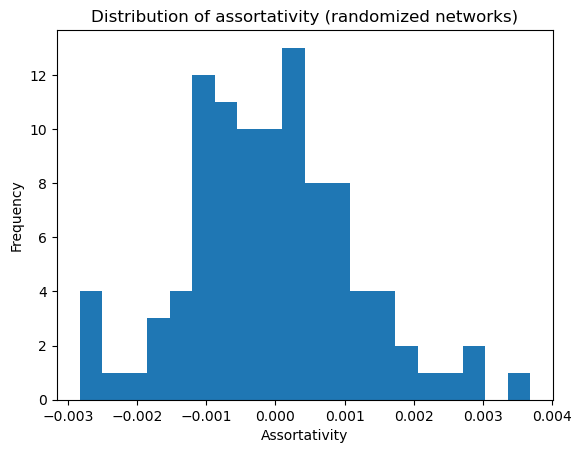

In [140]:
import matplotlib.pyplot as plt

plt.hist(Assortativity_scores, bins=20)
plt.xlabel("Assortativity")
plt.ylabel("Frequency")
plt.title("Distribution of assortativity (randomized networks)")
plt.show()

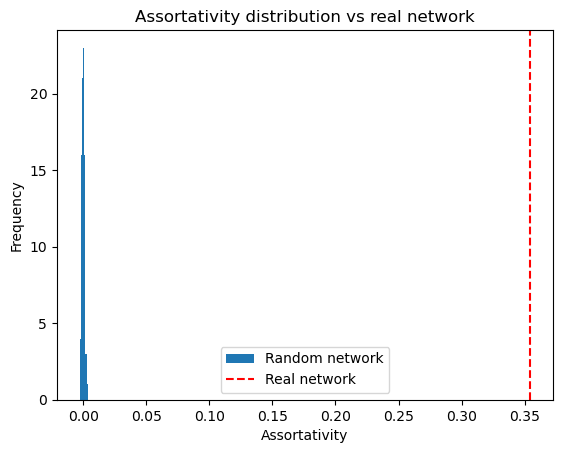

In [141]:
import matplotlib.pyplot as plt
real_r = G_Assortativity(G_valid, False)

plt.hist(Assortativity_scores, bins=10,label="Random network")
plt.axvline(real_r, color="red", linestyle="--", label="Real network")

plt.xlabel("Assortativity")
plt.ylabel("Frequency")
plt.title("Assortativity distribution vs real network")
plt.legend()
plt.show()

In [142]:
# Calculating the confidence interval of the 100 random generated networks:
import scipy.stats as stats

def confidence_intervals(data): #Mean confidence intevall for 95%
    (CI_low,CI_high) = stats.ttest_1samp(data, popmean=0).confidence_interval(confidence_level=0.975)
    return CI_low,CI_high

print(f"Confidence inteval random: {confidence_intervals(Assortativity_scores)} \nReal network: {real_r}")


Confidence inteval random: (-0.0003211609760511164, 0.00023643488778056414) 
Real network: 0.3545461109206213


<span style="color:red;">
The assortativity of the real network lies outside the distribution of assortativity values from randomized networks (confidence_intervals 95%). This suggests that collaborations between authors from the same country occur more frequently than expected by chance.
</span> <br>

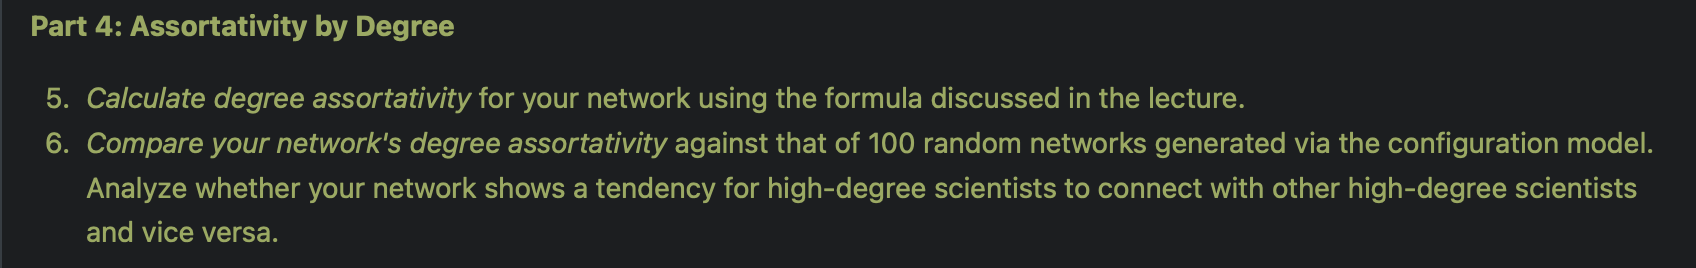

<span style="color:red;">
Same as before, we have created a script that uses MC to speed up the proces. The assortativity_Degree_MC.py script and the CSV file is in the Github. We used nx.degree_assortativity_coefficient() as we were unsure what formula to use.
</span> <br>


In [143]:
df = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week_6/assortativity_Degree_scores.csv")
Assortativity_scores_degree = df["0"].tolist()

print(f"length {len(Assortativity_scores_degree)}")
print(f"mean {np.mean(Assortativity_scores_degree)}")
print(f"std {np.std(Assortativity_scores_degree)}")

length 300
mean -0.006863094407779519
std 0.0025545547238757043


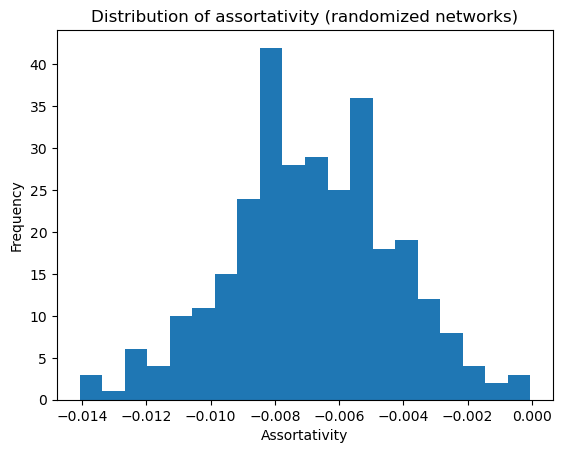

In [144]:
plt.hist(Assortativity_scores_degree, bins=20)
plt.xlabel("Assortativity")
plt.ylabel("Frequency")
plt.title("Distribution of assortativity (randomized networks)")
plt.show()

-0.05591903038764486


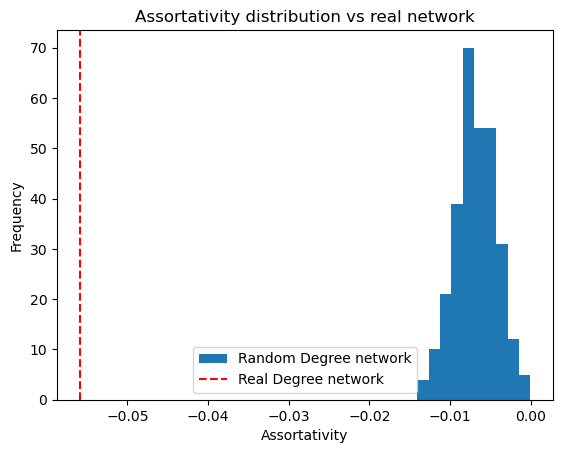

In [145]:
real_degree_r = nx.degree_assortativity_coefficient(G_valid)
print(real_degree_r)

plt.hist(Assortativity_scores_degree, bins=10,label="Random Degree network")
plt.axvline(real_degree_r, color="red", linestyle="--", label="Real Degree network")

plt.xlabel("Assortativity")
plt.ylabel("Frequency")
plt.title("Assortativity distribution vs real network")
plt.legend()
plt.show()

In [146]:
# Calculating the confidence interval of the 300 random generated networks
import scipy.stats as stats

def confidence_intervals(data): #Mean confidence intevall for 95%
    (CI_low,CI_high) = stats.ttest_1samp(data, popmean=0).confidence_interval(confidence_level=0.975)
    return CI_low,CI_high
print(f"Confidence inteval: {confidence_intervals(Assortativity_scores_degree)} \nReal network: {real_degree_r}")

Confidence inteval: (-0.007195901078008582, -0.006530287737550456) 
Real network: -0.05591903038764486


<span style="color:red;">
The network is disassortative, with high-degree nodes connecting to low-degree nodes compared to random networks. Indicating hub like behavoir in the network, which also can be seen in the network figure. 
</span> <br>

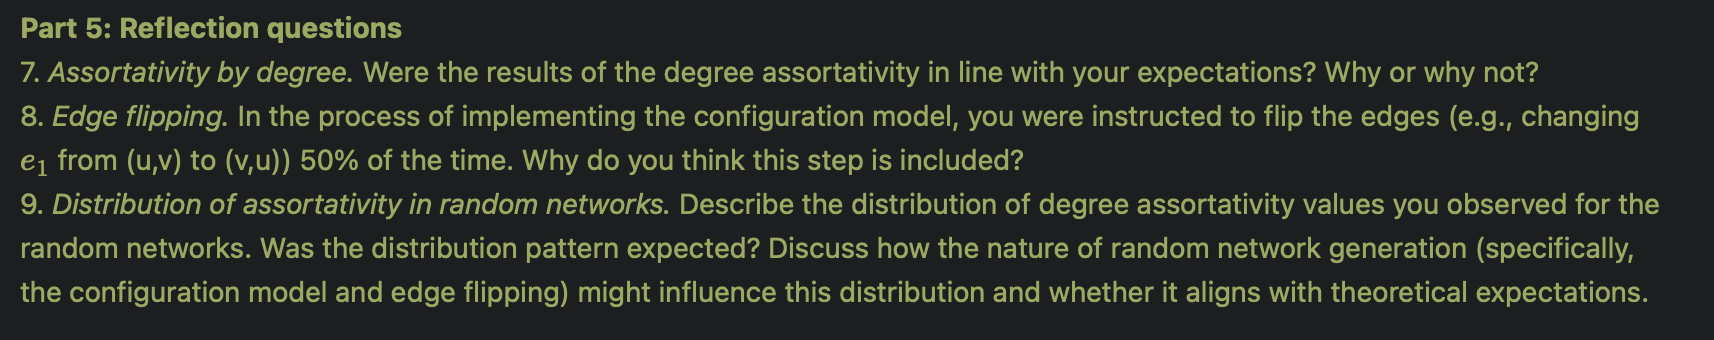

<span style="color:red;">7. The results indicate the the network is sligtly disassortative, with our real network lying outside the ranbom distribution. Its way closer to the random disbritution, then it was for the country assortative score. We expected to some disassortative, as many contributors often contribute with many different authors, not only the biggest ones. </span> <br>

<span style="color:red;">8. To ensure fair comparison between the real and random networks. We only keep degree knowlagde, so how many each node is connected to, but to whom we are connected to is random. Edge swapping is used to randomize the network while preserving the degree sequence, allowing us to isolate whether observed assortativity arises from structural patterns beyond node degree. </span> <br>

<span style="color:red;">9. The distribution of degree assortativity values for the randomized networks is approximately normal disbritution and centered slightly below zero, indicating weak disassortative mixing. This pattern is expected, as the configuration model preserves the degree sequence while randomizing connections, removing any strong structural correlations.  The narrow spread of the distribution reflects the fact that all randomized networks share the same degree sequence, leading to limited variation in assortativity.</span>

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?
> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).
> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?
> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

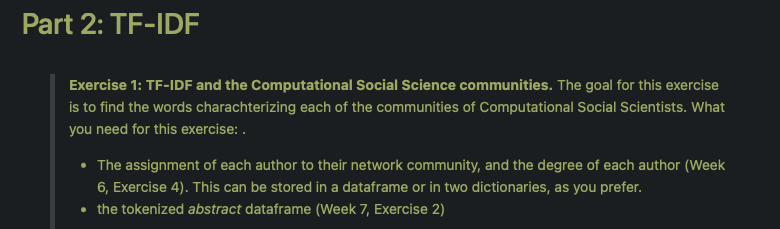
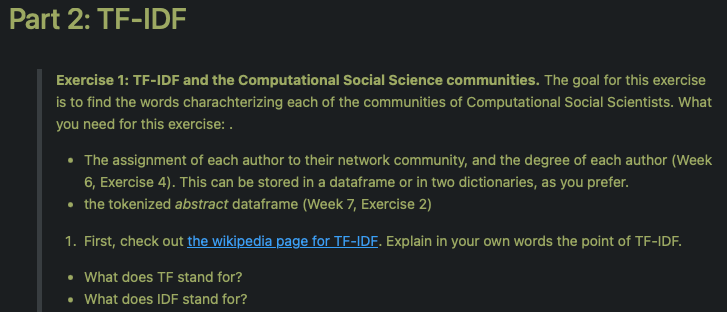

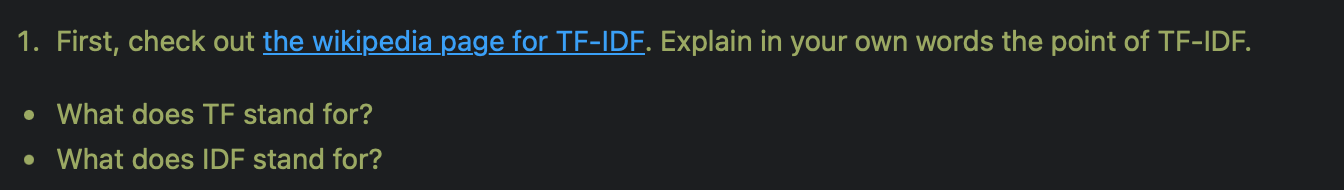

<span style="color:red;">
TF stands for term frequancy, so the relative frequency of term t within document. 

<br>

The inverse document frequency (IDF) is a measure of how much information the word provides, i.e., how common or rare it is across all documents.
</span> <br>


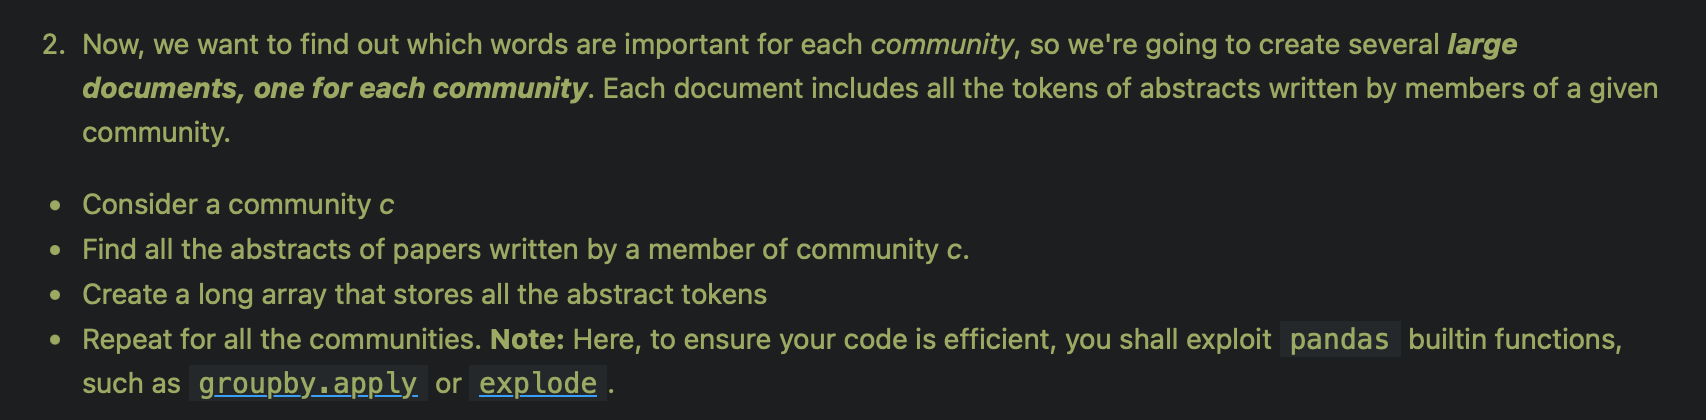

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import scipy.stats as stats
import itertools as iter
import ast
import random
from collections import Counter
random = random.seed(42)

In [148]:
#Because we have the datasets split, and need to merge them, we load them here.
Authors_w_c = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week_6/D7_CSS_Authors_w_communities.csv")
Authors_w_c = Authors_w_c.dropna(subset=["community"])
print(Authors_w_c["community"].max())

Abstract_tokens = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week_7/D9_CSS_Abstracts_tokenized.csv")
Abstract_tokens = Abstract_tokens.dropna(subset=["abstract_inverted_index"])
print(len(Abstract_tokens))

Papers = pd.read_csv("/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Week 3/FInal_data/D8_CSS_Papers.csv")
print(len(Papers))

Papers_AbstractsTOKEN_Authors = Abstract_tokens.merge(Papers, on="work_id", how="inner")

93.0
87816
120877


In [149]:
#Now we need to explode every single work_id by the author_ids, meaning we have a row for each author for each word_id
# Then we can map each communuty to each row corresponding to each author in the dataframe
df = Papers_AbstractsTOKEN_Authors.copy()
df = df.dropna(subset=["tokens"])

df["author_ids"] = df["author_ids"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df = df.explode("author_ids")

author_to_community = dict(zip(Authors_w_c["author_id"], Authors_w_c["community"]))
df["community"] = df["author_ids"].map(author_to_community)
df = df.dropna(subset=["community"])

df["tokens"] = df["tokens"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

#here we group all the tokens for each community repectivly 
community_tokens = (
    df.groupby("community")["tokens"]
    .apply(lambda lists: [token for sublist in lists for token in sublist])
)
df_explode = df
df.head(5)

,work_id,title,abstract_inverted_index,text,tokens,publication_year,cited_by_count,author_ids,community
0,https://openalex.org/W2047940964,Finding community structure in very large netw...,"{'The': [0, 158], 'discovery': [1], 'and': [2,...",The discovery and analysis of community struct...,"[discovery, analysis, community_structure, net...",2004.0,7328,https://openalex.org/A5014647140,1.0
0,https://openalex.org/W2047940964,Finding community structure in very large netw...,"{'The': [0, 158], 'discovery': [1], 'and': [2,...",The discovery and analysis of community struct...,"[discovery, analysis, community_structure, net...",2004.0,7328,https://openalex.org/A5067142016,1.0
0,https://openalex.org/W2047940964,Finding community structure in very large netw...,"{'The': [0, 158], 'discovery': [1], 'and': [2,...",The discovery and analysis of community struct...,"[discovery, analysis, community_structure, net...",2004.0,7328,https://openalex.org/A5008033989,1.0
1,https://openalex.org/W3103362336,Power-law distributions in empirical data,"{'Power-law': [0], 'distributions': [1, 64], '...",Power-law distributions occur in many situatio...,"[distribution, occur, many, situation, scienti...",2018.0,6724,https://openalex.org/A5014647140,1.0
1,https://openalex.org/W3103362336,Power-law distributions in empirical data,"{'Power-law': [0], 'distributions': [1, 64], '...",Power-law distributions occur in many situatio...,"[distribution, occur, many, situation, scienti...",2018.0,6724,https://openalex.org/A5082953212,1.0


In [150]:
#to check if it works:
print(len(community_tokens))       # number of communities
print(len(community_tokens.iloc[10]))  # number of tokens in community
print(community_tokens.iloc[10][:10])  # the first tens tokens

94
9872
['investigated', 'transportation', 'accessibility', 'special', 'need', 'population', 'special', 'need', 'shelter', 'spns']


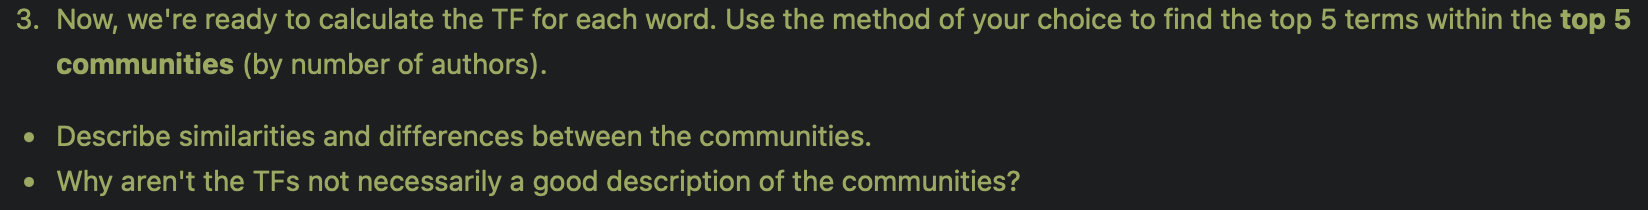

In [151]:
comm_sizes = (
    df.groupby("community")["author_ids"]
    .nunique()
    .to_dict()
)

top5_comms = sorted(comm_sizes, key=comm_sizes.get, reverse=True)[:5]
rows = []

for comm in top5_comms:
    tokens = community_tokens.loc[comm]
    counts = Counter(tokens)
    total_words = sum(counts.values())
    n_authors = comm_sizes[comm]

    for word, count in counts.most_common(5):
        rows.append({
            "community": comm,
            "word": word,
            "count": count,
            "total_words": total_words,
            "tf": count / total_words,
            "n_authors": n_authors 
        })

df_tf = pd.DataFrame(rows)
print(df_tf)

    community         word  count  total_words        tf  n_authors
0         4.0      network  11801      1234297  0.009561       1485
1         4.0        model   7605      1234297  0.006161       1485
2         4.0       system   5648      1234297  0.004576       1485
3         4.0        study   5325      1234297  0.004314       1485
4         4.0         show   4663      1234297  0.003778       1485
5         1.0         user   6866      1347747  0.005094       1264
6         1.0        model   6627      1347747  0.004917       1264
7         1.0         data   6150      1347747  0.004563       1264
8         1.0       system   4986      1347747  0.003700       1264
9         1.0    algorithm   4685      1347747  0.003476       1264
10       37.0        model   4330       916086  0.004727       1081
11       37.0       people   3839       916086  0.004191       1081
12       37.0        study   3747       916086  0.004090       1081
13       37.0       effect   3693       916086  

<span style="color:red;">
The top communities share words like "model", "system" and "data". Which makes sense as those types of words are commen across research papers. Community 9,4,1 seem similar focusning on methods, tasks and etc. Where community 37 seems to be more human centered, as terms like "people", "participants" are among the top words. 

<br>

TF is alone not a good indicator of description of the community, as it only captures the most common words, which may be commen across all communities. This make it difficult to idenfity what terms defines each community.
</span> <br>

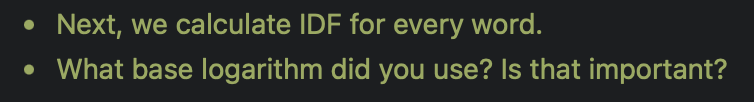

In [152]:
All_doc = Abstract_tokens
All_doc["tokens"] = All_doc["tokens"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

D = len(All_doc)

doc_freq = Counter()
for tokens in All_doc["tokens"]:
    for word in set(tokens):
        doc_freq[word] += 1

rows = []

for comm in top5_comms:
    tokens = community_tokens.loc[comm]
    counts = Counter(tokens)
    total_words = sum(counts.values())
    n_authors = comm_sizes[comm]

    for word, count in counts.most_common(5):
        nt = doc_freq[word]
        idf = np.log((1 + D) / (1 + nt)) 
        
        rows.append({
            "community": int(comm),
            "word": word,
            "count": count,
            "total_words": total_words,
            "tf": count / total_words,
            "idf": idf,
            "n_authors": n_authors
        })

df_tf = pd.DataFrame(rows)
print(df_tf)

    community         word  count  total_words        tf       idf  n_authors
0           4      network  11801      1234297  0.009561  2.063995       1485
1           4        model   7605      1234297  0.006161  1.477774       1485
2           4       system   5648      1234297  0.004576  1.975049       1485
3           4        study   5325      1234297  0.004314  1.640807       1485
4           4         show   4663      1234297  0.003778  1.719050       1485
5           1         user   6866      1347747  0.005094  2.502008       1264
6           1        model   6627      1347747  0.004917  1.477774       1264
7           1         data   6150      1347747  0.004563  1.745835       1264
8           1       system   4986      1347747  0.003700  1.975049       1264
9           1    algorithm   4685      1347747  0.003476  2.479059       1264
10         37        model   4330       916086  0.004727  1.477774       1081
11         37       people   3839       916086  0.004191  2.6099

WIKIPEDIA: 



$\operatorname{idf}(t, D)=\log \frac{N}{n_t}$

- D: is the set of all documents in the corpus
- $N=|D|$ : total number of documents in the corpus
- $n_t=|\{d \in D: t \in d\}|$ : number of documents where the term $t$ appears (i.e., $\mathrm{tf}(t, d) \neq 0$ ). If the term is not in the corpus, this will lead to a division-by-zero. It is therefore common to adjust the numerator to $1+N$ and the denominator to $1+|\{d \in D: t \in d\}|$.

<span style="color:red;">
We use the inbuilt np.log, which is the natural logaritm. The log which is use, is not that important as it only recales the IDF by a constant. 
</span> <br>

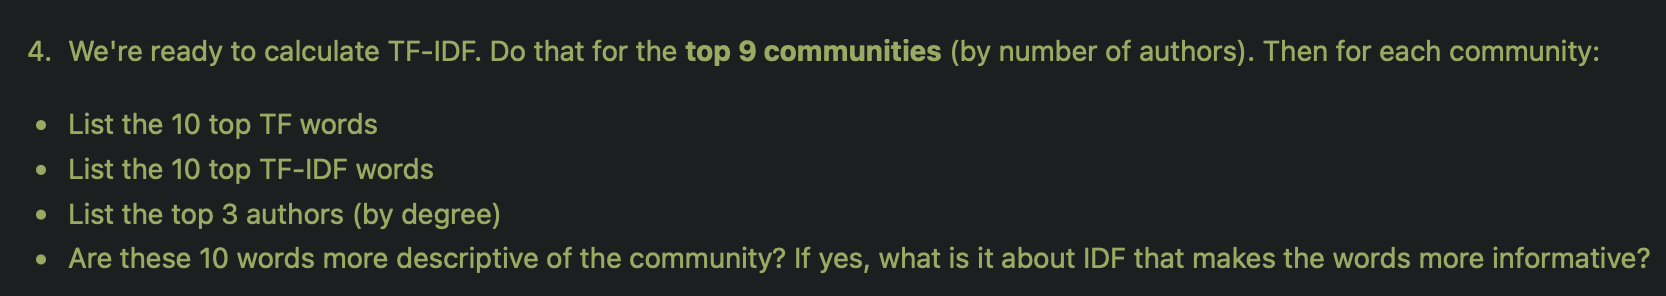

In [153]:
rows = []

top9_comms = sorted(comm_sizes, key=comm_sizes.get, reverse=True)[:9]

for comm in top9_comms:
    tokens = community_tokens.loc[comm]
    counts = Counter(tokens)
    total_words = sum(counts.values())
    n_authors = comm_sizes[comm]

    for word, count in counts.items():  
        nt = doc_freq[word]
        tf = count / total_words
        idf = np.log((1 + D) / (1 + nt))
        tfidf = tf * idf

        rows.append({
            "community": int(comm),
            "word": word,
            "count": count,
            "total_words": total_words,
            "tf": tf,
            "idf": idf,
            "tf-idf": tfidf,
            "n_authors": n_authors
        })

df = pd.DataFrame(rows)

In [154]:
top_tf = (
    df.sort_values(["community", "tf"], ascending=[True, False])
      .groupby("community")
      .head(10)
)

top_tf.head(15)

,community,word,count,total_words,tf,idf,tf-idf,n_authors
27662,1,user,6866,1347747,0.005094,2.502008,0.012746,1264
27554,1,model,6627,1347747,0.004917,1.477774,0.007266,1264
27328,1,data,6150,1347747,0.004563,1.745835,0.007967,1264
27452,1,system,4986,1347747,0.003700,1.975049,0.007307,1264
27250,1,algorithm,4685,1347747,0.003476,2.479059,0.008618,1264
27286,1,show,4540,1347747,0.003369,1.719050,0.005791,1264
28386,1,problem,4466,1347747,0.003314,2.080000,0.006892,1264
27838,1,work,4280,1347747,0.003176,2.268300,0.007203,1264
27234,1,network,4249,1347747,0.003153,2.063995,0.006507,1264
27726,1,paper,4206,1347747,0.003121,1.679560,0.005242,1264


In [155]:
top_tfidf = (
    df.sort_values(["community", "tf-idf"], ascending=[True, False])
      .groupby("community")
      .head(10)
)

top_tfidf.head(15)

,community,word,count,total_words,tf,idf,tf-idf,n_authors
27662,1,user,6866,1347747,0.005094,2.502008,0.012746,1264
27250,1,algorithm,4685,1347747,0.003476,2.479059,0.008618,1264
27328,1,data,6150,1347747,0.004563,1.745835,0.007967,1264
27241,1,community,3180,1347747,0.002359,3.240947,0.007647,1264
27637,1,graph,2823,1347747,0.002095,3.589424,0.007518,1264
27452,1,system,4986,1347747,0.003700,1.975049,0.007307,1264
27554,1,model,6627,1347747,0.004917,1.477774,0.007266,1264
27838,1,work,4280,1347747,0.003176,2.268300,0.007203,1264
28340,1,task,4060,1347747,0.003012,2.322447,0.006996,1264
28386,1,problem,4466,1347747,0.003314,2.080000,0.006892,1264


In [156]:
#top 10 words for each community, in a table.
top_tfidf_wide = (
    top_tfidf.groupby("community")["word"]
    .apply(list)
    .apply(pd.Series)
    .T
)
print(len(top_tfidf_wide))


top_tfidf_wide.index = [f"word_{i+1}" for i in range(len(top_tfidf_wide))]
top_tfidf_wide

10


community,1,2,4,5,7,9,18,25,37
word_1,user,firm,network,political,twin,model,personality,image,people
word_2,algorithm,product,node,news,genetic,task,student,video,participant
word_3,data,market,dynamic,medium,child,text,personality_trait,feature,belief
word_4,community,business,model,party,migration,language,change,propose,misinformation
word_5,graph,innovation,system,social_medium,data,word,trait,method,effect
word_6,system,find,find,populist,family,sentence,effect,model,judgment
word_7,model,productivity,distribution,citizen,age,method,study,learning,memory
word_8,work,data,study,effect,fertility,training,n,object,decision
word_9,task,organization,epidemic,partisan,individual,natural_language,adolescent,network,theory
word_10,problem,price,individual,public,woman,learning,participant,proposed,model


<span style="color:red;">
Yes the words are way more descriptive of the communuity, becaues it takes account for commen words that appear accross all the documents, where rare and maybe more informative words are found by TF-IDF.
</span> <br>

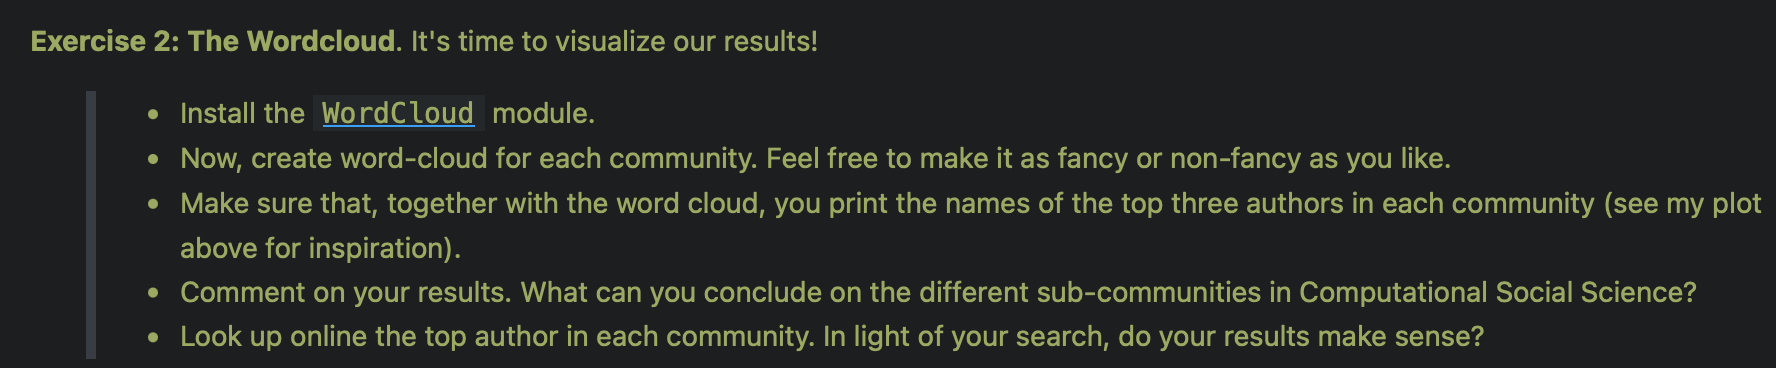

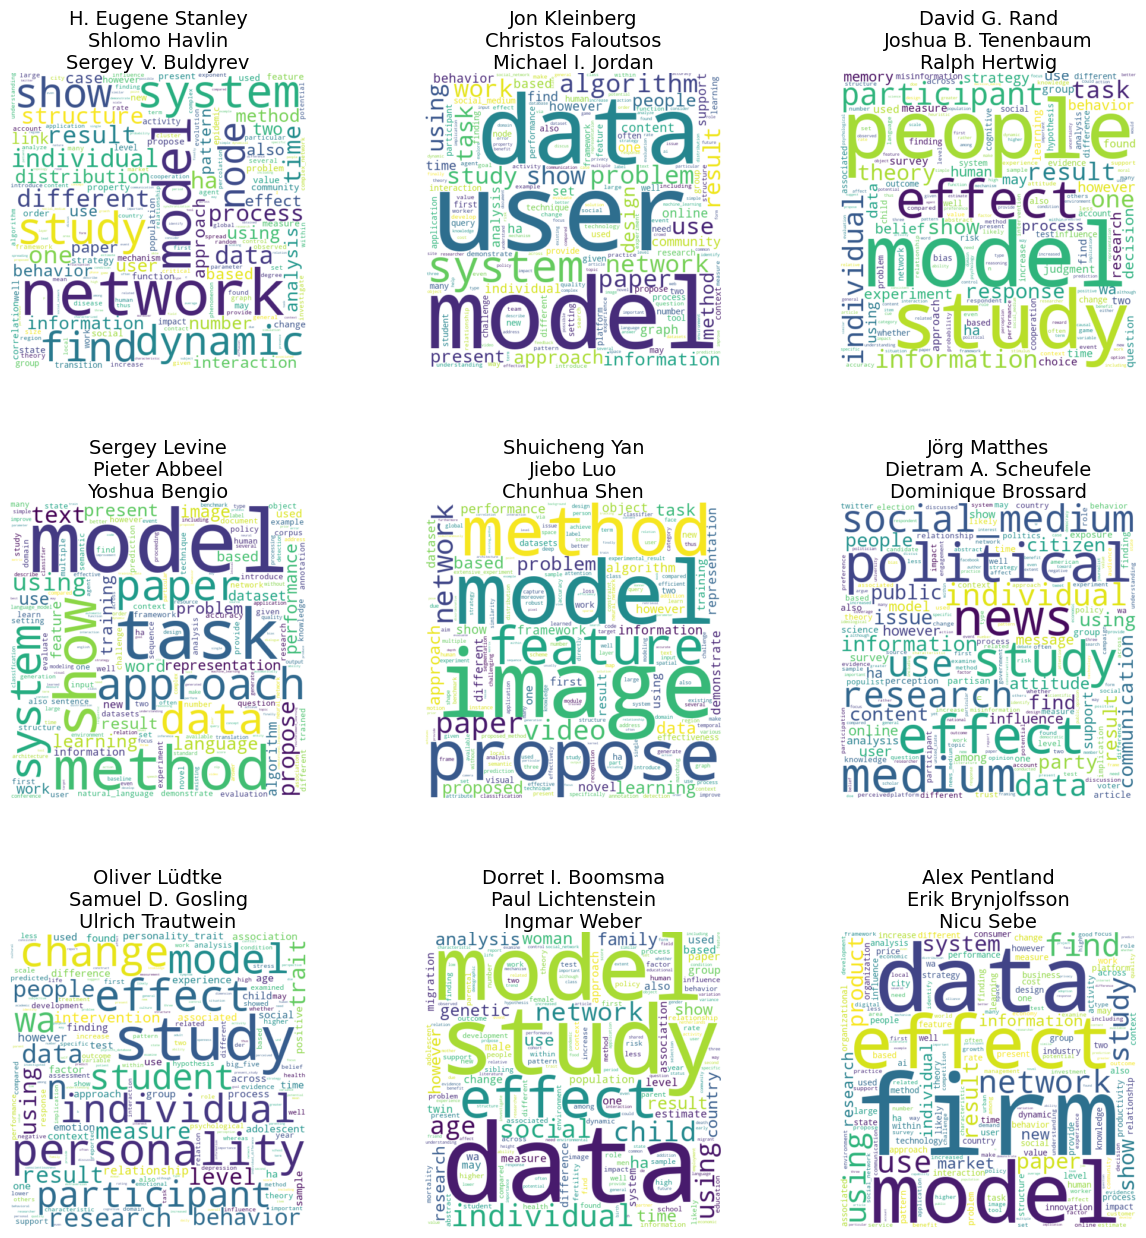

In [157]:
from wordcloud import WordCloud

#we already have each community from before 
top9_comms = sorted(comm_sizes, key=comm_sizes.get, reverse=True)[:9]


#find top authoers and their names 
author_counts = (
    df_explode.groupby(["community", "author_ids"])
    .size()
    .reset_index(name="n_papers")
)
author_counts_named = author_counts.merge(
    Authors_w_c[["id", "display_name"]],
    left_on="author_ids",
    right_on="id",
    how="left"
)
top3_authors = (
    author_counts_named
    .sort_values(["community", "n_papers"], ascending=[True, False])
    .groupby("community")
    .head(3)
)


#plot the wordcloads with top 9 authors
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, comm in enumerate(top9_comms):
    tokens = community_tokens.loc[comm]
    counts = Counter(tokens)
    wc = WordCloud(
    width=500,
    height=500,
    background_color="white"
    ).generate_from_frequencies(counts)

    ax = axes[i]
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")

    authors_here = top3_authors[top3_authors["community"] == comm]["display_name"].fillna(
        top3_authors[top3_authors["community"] == comm]["author_ids"]
    ).tolist()

    ax.text(
        0.5, 1,
        "\n".join(authors_here),
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14
    )

fig.subplots_adjust(hspace=0.45, wspace=0.25)
plt.show()

<span style="color:red;">
It is actually very interesting seeing this diverse subgroups in computational social science, but it make sense. All of them have to do with model/data/study which is at the core of ComSocSci. Its quite clear how some subgroups differ from eachother. Some are studying images, other political science, and some networks. 

<br>


When searching some of the authors up, for exampes Jorg Matthes he works with communication, digital media effects and political science, which matches the wordcloud for the group. Searcing for Shuicheng Yan, he is known for AI, computer vision and ML. Which makes sense, if you look at the wordcload, with words like images, features, model, video etc. To sum up, it seems like the wordclouds are captures some main aspects of computational social science, and its core elements.

</span> <br>

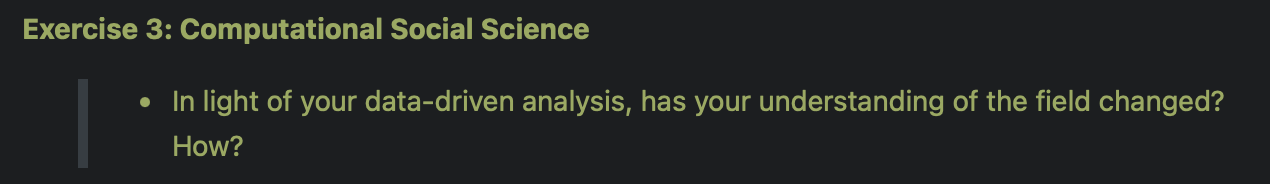

<span style="color:red;">
The data-driven analysis changed our understanding of CSS in several concrete ways.
First, the country assortativity coefficient of the real network fell outside the 95% confidence interval of 100 randomized networks generated via the configuration model, providing statistically significant evidence that researchers collaborate far more with others from the same country than expected by chance. This was surprising for a field that studies digital and online phenomena, which we assumed would be more internationally integrated.

<br>

Second, the degree assortativity of the network was approximately -0.056, and again fell outside the distribution of random networks, confirming that the network is disassortative. This means high-degree researchers, the central hubs of CSS, predominantly co-author with lower-degree researchers, rather than clustering among themselves. This paint a picture of a field with a small elite of highly connected scholars driving much of the collobaration.
<br>

Third, the TF-IDF analysis of the top communities revealed that CSS is far more fragmented than expected. Community 4 (1485 authors) is centered around network science ("network", "model", "system"), community 37 (1081 authors) appears distinctly human-centered ("people", "participants", "effect"), community 25 (933 authors) focuses on computer vision ("image", "feature", "propose"), andcommunity 2 (669 authors) focuses on organizational economics ("firm","product","business"). Together, these findings suggest that CSS is less a unified discipline and more a loose collection of methodologically and thematically diverse sub-fields.
</span> <br>



